In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

In [3]:
class MLPRegression(nn.Module):
    def __init__(self, input_dim, hidden_dim): #构造函数，需要调用nn.Mudule的构造函数
        super().__init__()       #等价于nn.Module.__init__()
        self.linear_hidden = nn.Linear(input_dim, hidden_dim)
        #nn.Parameter(torch.randn(input_dim + 1, hidden_dim))
        self.linear_output = nn.Linear(hidden_dim, 1) 
        self.activation = nn.Sigmoid() #Identity()

    def forward(self, x):
        #x = torch.cat([x, torch.ones((x.shape[0],1))], dim = 1)
        hidden_layer_output = self.activation(self.linear_hidden(x))
        y = self.activation(self.linear_output(hidden_layer_output))
        return y

    def show_info(self):
        for name, parameter in self.named_parameters():
            print(name, '\n',parameter)
            print('-------------------')

In [4]:
def TestMLPRegression():
    input_dim = 3
    hidden_dim = 4

    MLPR_model = MLPRegression(input_dim, hidden_dim)
    MLPR_model.show_info()

TestMLPRegression()

linear_hidden.weight 
 Parameter containing:
tensor([[-0.0386,  0.0977,  0.3674],
        [ 0.0037, -0.1225, -0.1591],
        [-0.5259, -0.3266, -0.2277],
        [ 0.0930, -0.1838, -0.2983]], requires_grad=True)
-------------------
linear_hidden.bias 
 Parameter containing:
tensor([-0.1962,  0.2090,  0.0916, -0.3614], requires_grad=True)
-------------------
linear_output.weight 
 Parameter containing:
tensor([[-0.3815,  0.1841,  0.3290, -0.1351]], requires_grad=True)
-------------------
linear_output.bias 
 Parameter containing:
tensor([-0.1166], requires_grad=True)
-------------------


In [ ]:
class MLP_Model(): #训练模型
    def __init__(self, input_dim, lr=0.01, epoches=10000, hidden_dim=3):
        """
        创建模型和优化器，初始化线性模型和优化器超参数
        """       
        # 模型超参数
        self.learning_rate = lr
        self.epoches = epoches
        self.hidden_dim = hidden_dim

        # 模型
        self.model = MLPRegression(input_dim, self.hidden_dim)
        # 优化器
        self.optimizer = torch.optim.SGD(self.model.parameters(), lr=self.learning_rate)
        # 损失函数
        self.loss_function = torch.nn.MSELoss()
    
    def train(self, x, y):
        """
        训练模型
        输入:
            x: 训练数据
            y: 回归真值
        返回: 
            losses: 所有迭代中损失函数值
        """
        losses = []

        for epoch in range(self.epoches):
            prediction = self.model(x) # y_hat
            loss = self.loss_function(prediction, y)  #L(y, y_hat) ，最终的输出结果是什么？     

            self.optimizer.zero_grad()#
            loss.backward()#dL/dw
            self.optimizer.step() #w = w - dL/dw

            losses.append(loss.item())

            if epoch % 500 == 0:
                print("epoch: {}, loss is: {}".format(epoch, loss.item()))

        if x.shape[1]==1:
            plt.figure()
            plt.scatter(x.data, y.data)
            plt.scatter(x.data, prediction.data, color="r")
            plt.show()

        return losses
        
    def test(self, x, y, if_plot = True):
        """
        用训练好的模型做测试
        输入:
            x: 测试数据
            y: 测试数据的回归真值
        返回:
            prediction: 测试数据的预测值
        """
        prediction = self.model(x)
        testMSE = self.loss_function(prediction, y)
        
        if if_plot and x.shape[1]==1:
            plt.figure()
            plt.scatter(x.data, y.data)
            plt.scatter(x.data, prediction.data, color="r")
            plt.show()

        return prediction, testMSE

In [8]:
def create_data(data_size, input_dim, if_plot=True):
    """
    为线性模型生成数据
    输入:
        data_size: 样本数量
        input_dim: 输入维度（特征数）
    返回:
        x_train: 训练数据
        y_train: 训练数据回归真值
        x_test: 测试数据
        y_test: 测试数据回归真值
    """
    # 固定随机数生成器种子，保证每次运行结果一致
    np.random.seed(1125)
    torch.manual_seed(1125)
    torch.cuda.manual_seed(1125)

    # 生成随机数据
    x = 7.0 * torch.rand(data_size, in_dim) + 0.15
    random_error = 0.1 * torch.rand(data_size, 1) - 0.05
    #y = 0.25 * torch.sum(torch.sin(x), dim=1, keepdim=True) + 0.5 + random_error
    y = 0.25 * torch.sum(torch.sin(x), dim=1, keepdim=True) + 0.5 + random_error

    #print(y)

    # 划分训练集与测试集
    shuffled_index = np.random.permutation(data_size)
    shuffled_index = torch.from_numpy(shuffled_index).long()
    x = x[shuffled_index]
    y = y[shuffled_index]
    split_index = int(data_size * 0.7)
    x_train = x[:split_index]     # 训练集 x
    y_train = y[:split_index]     # 训练集 y
    x_test = x[split_index:]      # 测试集 x
    y_test = y[split_index:]      # 测试集 y
    
    if if_plot and input_dim == 1:
        plt.figure()
        plt.scatter(x_train.numpy(),y_train.numpy())
        plt.show()
    return x_train, y_train, x_test, y_test

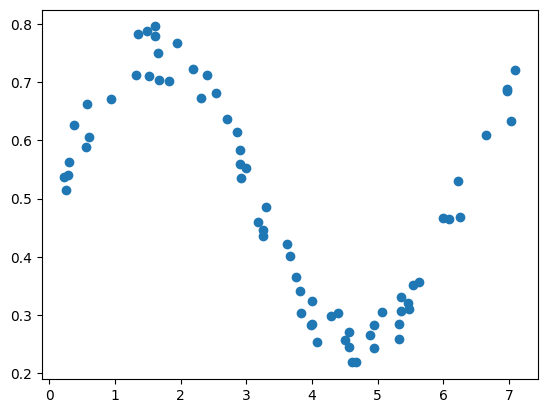

epoch: 0, loss is: 0.028258392587304115
epoch: 500, loss is: 0.022788764908909798
epoch: 1000, loss is: 0.021440057083964348
epoch: 1500, loss is: 0.02098332904279232
epoch: 2000, loss is: 0.02078063413500786
epoch: 2500, loss is: 0.020654674619436264
epoch: 3000, loss is: 0.020551780238747597
epoch: 3500, loss is: 0.020454250276088715
epoch: 4000, loss is: 0.020355520769953728
epoch: 4500, loss is: 0.02025272510945797
epoch: 5000, loss is: 0.02014429308474064
epoch: 5500, loss is: 0.02002922259271145
epoch: 6000, loss is: 0.019906766712665558
epoch: 6500, loss is: 0.019776320084929466
epoch: 7000, loss is: 0.01963735558092594
epoch: 7500, loss is: 0.019489387050271034
epoch: 8000, loss is: 0.019331948831677437
epoch: 8500, loss is: 0.01916460692882538
epoch: 9000, loss is: 0.018986927345395088
epoch: 9500, loss is: 0.018798524513840675
epoch: 10000, loss is: 0.018599046394228935
epoch: 10500, loss is: 0.018388191238045692
epoch: 11000, loss is: 0.018165724352002144
epoch: 11500, loss 

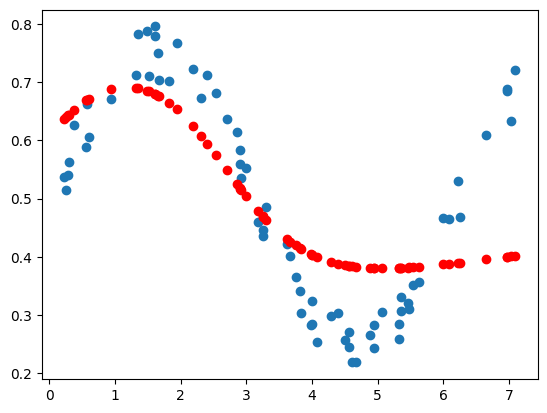

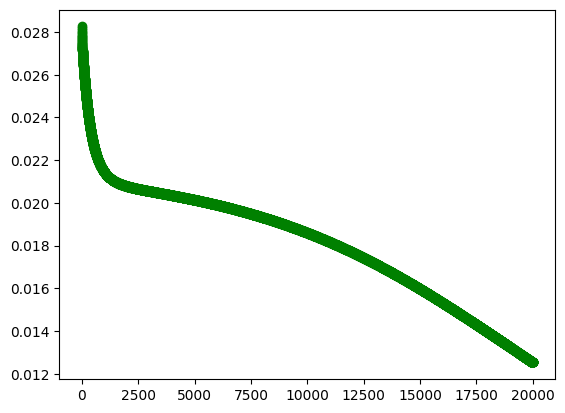

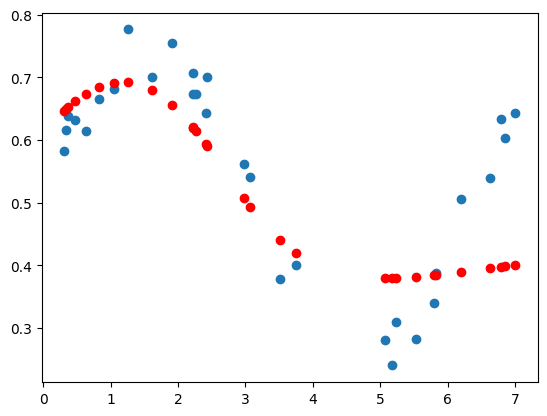

测试集上MSE损失值:0.010108817368745804
linear_hidden.weight Parameter containing:
tensor([[ 1.2912],
        [-0.2405],
        [-1.3998],
        [-0.5946],
        [-0.2282],
        [ 0.6002],
        [ 0.6059],
        [-0.4547],
        [ 1.5243],
        [-0.2159]], requires_grad=True)
linear_hidden.bias Parameter containing:
tensor([ 0.2740, -0.0902,  3.5917,  0.3824, -0.3856,  0.1344,  0.1431, -0.7646,
         0.0656, -0.7441], requires_grad=True)
linear_output.weight Parameter containing:
tensor([[ 0.5887, -1.0514,  2.1752, -0.2595, -0.9331, -0.4277, -0.5244, -0.1620,
          0.9438, -0.7380]], requires_grad=True)
linear_output.bias Parameter containing:
tensor([-0.6560], requires_grad=True)


In [9]:
# 生成数据
data_size = 100
in_dim = 1
x_train, y_train, x_test, y_test = create_data(data_size, in_dim, if_plot=True)

# 线性回归模型实例化
MLP = MLP_Model(in_dim, lr=0.1, epoches=20000, hidden_dim=10) # 1 x 10 x 1
# 模型训练
losses = MLP.train(x_train, y_train)

# 画图
plt.figure()
plt.scatter(np.arange(len(losses)), losses, marker='o', c='green')
# plt.savefig('loss.jpg')   # 保存图片
#plt.show()
# 模型测试
prediction, testMSE = MLP.test(x_test, y_test)
print('测试集上MSE损失值:{}'.format(testMSE))

for name,parameter in MLP.model.named_parameters():
    print(name, parameter)